整合模型：ARIMA($p,d,q$)

ARIMA模型的核心是将自回归（AR）、差分（I）和滑动平均（MA）三部分结合起来。完整的ARIMA($p,d,q$)模型公式为：
$$\phi(B) \nabla^d y_t = \theta(B) \epsilon_t$$
推导：
1. 首先，通过 $d$ 次差分操作 $\nabla^d $，我们将原始的非平稳序列 $y_t $转化为平稳序列。
2. 然后，平稳的序列通过AR($p$)的滞后值和MA($q$)的滞后误差项来描述。
3. 最终的模型可以通过滞后算子 $\phi(B) $和 $\theta(B) $表达，将过去的滞后值和误差综合起来，预测当前的 $y_t $。

ARIMA 模型的适用场景
1. 稳定的时间序列预测：
ARIMA 模型非常适合对具有趋势或者季节性但可以通过差分处理变为平稳的数据进行预测。例如，销售数据、股票价格、温度变化等都可以使用 ARIMA 模型。
2. 短期预测：
ARIMA 在短期预测中的表现通常优于长期预测，因为它基于过去的滞后值和误差来预测未来的变化，所以在数据具有短期依赖性的场景下，ARIMA 效果较好。
3. 单变量时间序列：
当只有一个变量的历史数据可用时，ARIMA 是一个合适的选择，尤其是对历史数据没有明显的复杂依赖关系时。
4. 经济和金融时间序列分析：
在经济和金融领域，ARIMA 被广泛应用于市场趋势预测、股票价格走势预测、宏观经济指标分析（如 GDP、CPI、汇率等）。

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)
data_rng = pd.date_range(start='1/1/2015', end='12/31/2023', freq='D')
n = len(data_rng)

In [15]:
trend = np.linspace(100, 500, n)
seasonality = 50 * np.sin(2 * np.pi * data_rng.dayofyear / 365.25)  # 每年周期性波动  .dayofyear返回一年中的第几天
noise = np.random.normal(0, 20, n)

sales = trend + seasonality + noise

In [16]:
df = pd.DataFrame({'Date': data_rng, 'Sales': sales})
df.set_index('Date', inplace=True)

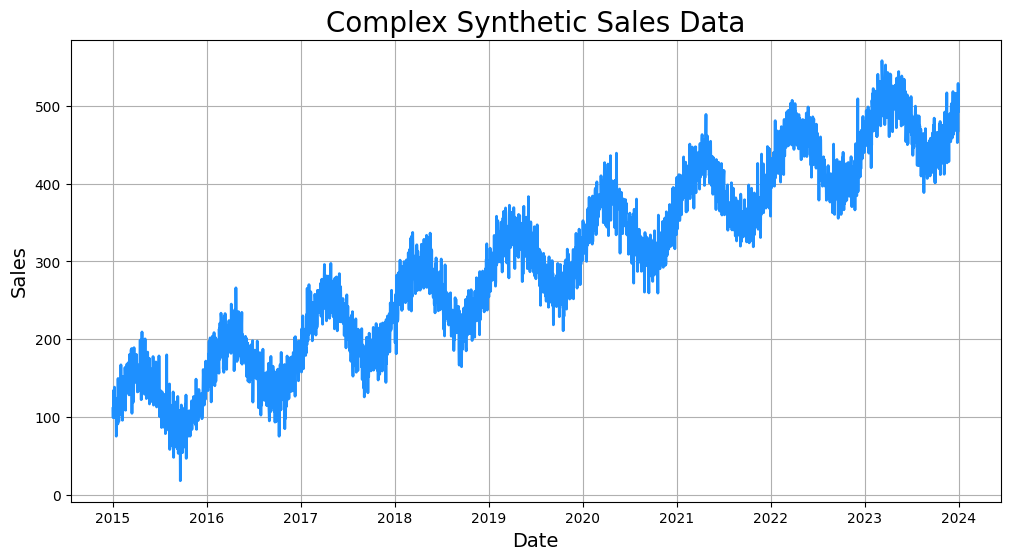

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], color='dodgerblue', linewidth=2)
plt.title('Complex Synthetic Sales Data', fontsize=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.grid(True)
plt.show()

In [18]:
df = df.asfreq('D')   # 对 DataFrame 调用，索引会变成日频
model = ARIMA(df['Sales'], order=(5, 1, 2))  # ARIMA(p=5, d=1, q=2)
arima_result = model.fit()

df['ARIMA_Prediction'] = arima_result.predict(start=0, end=len(df)-1, dynamic=False)

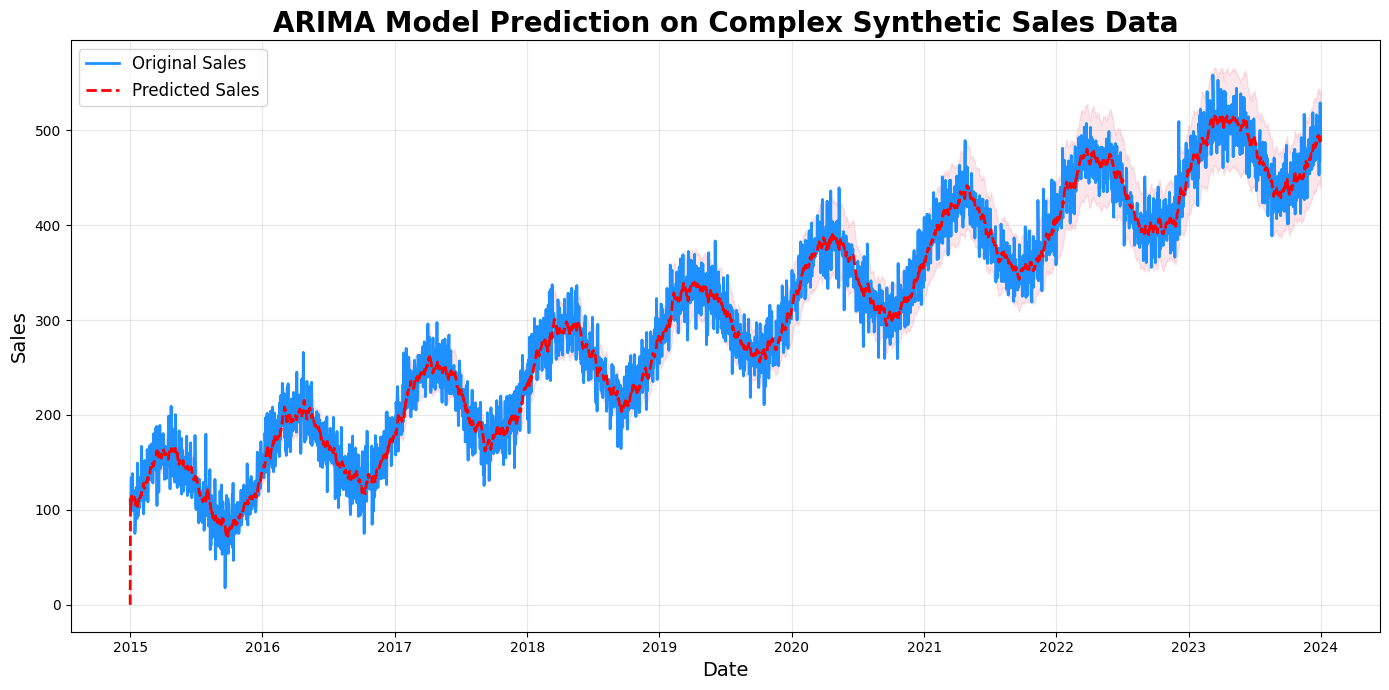

In [19]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Sales'], label='Original Sales', color='dodgerblue', linewidth=2)
plt.plot(df.index, df['ARIMA_Prediction'], label='Predicted Sales', color='red', linestyle='--', linewidth=2)
plt.fill_between(df.index, df['ARIMA_Prediction']*0.9, df['ARIMA_Prediction']*1.1, color='crimson', alpha=0.1)
plt.title('ARIMA Model Prediction on Complex Synthetic Sales Data', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

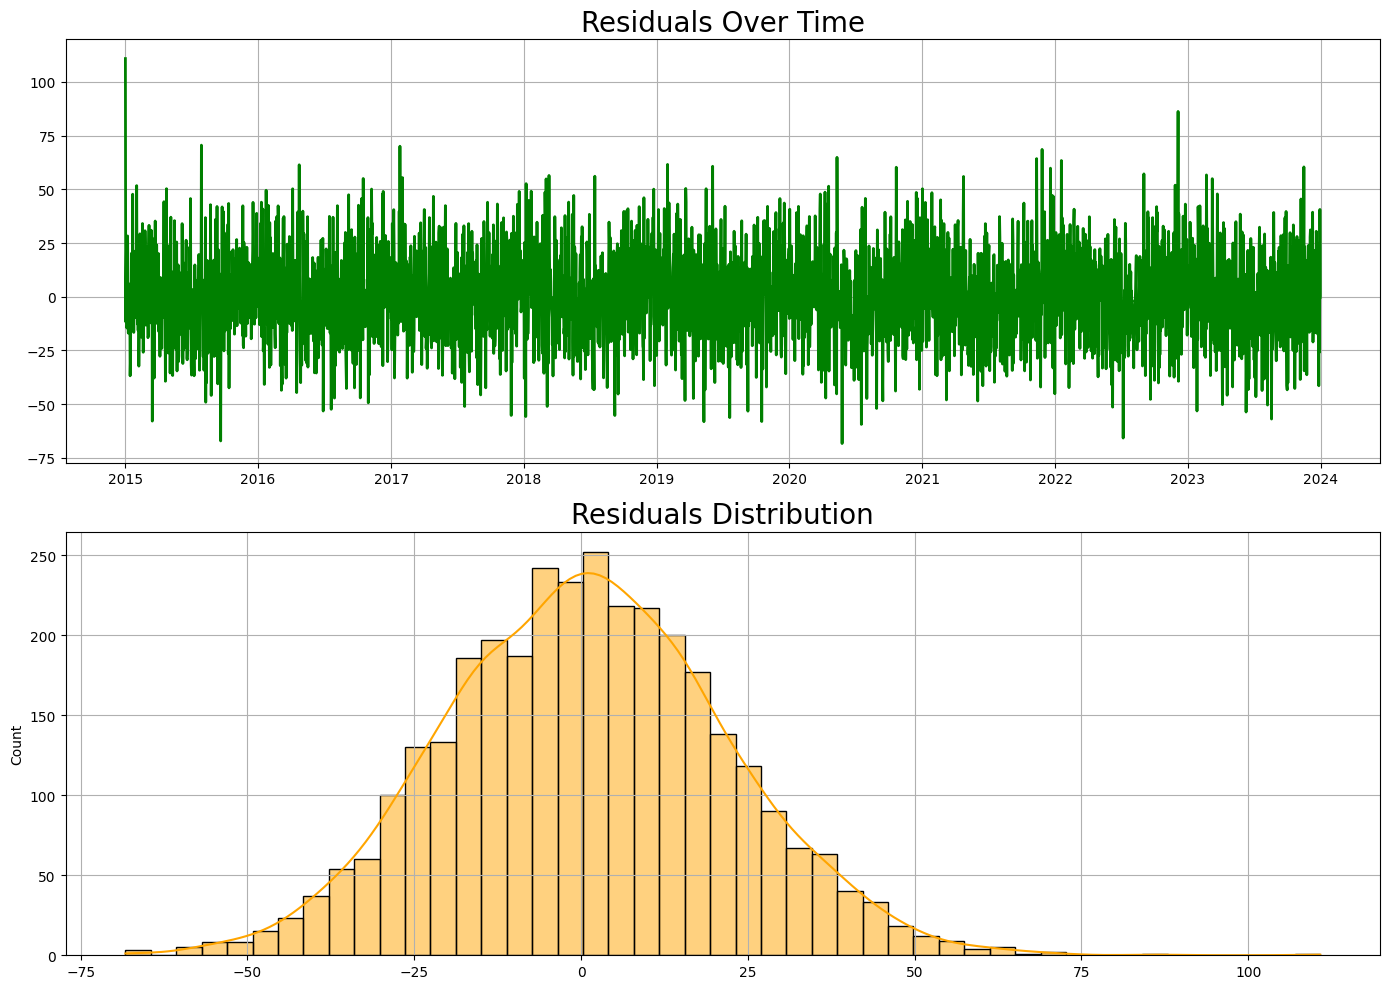

In [22]:
residuals = arima_result.resid
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

ax[0].plot(residuals, color='green', linestyle='-', linewidth=2)
ax[0].set_title('Residuals Over Time', fontsize=20)
ax[0].grid(True)

sns.histplot(residuals, kde=True, color='orange', ax=ax[1])
ax[1].set_title('Residuals Distribution', fontsize=20)
ax[1].grid(True)

plt.tight_layout()
plt.show()

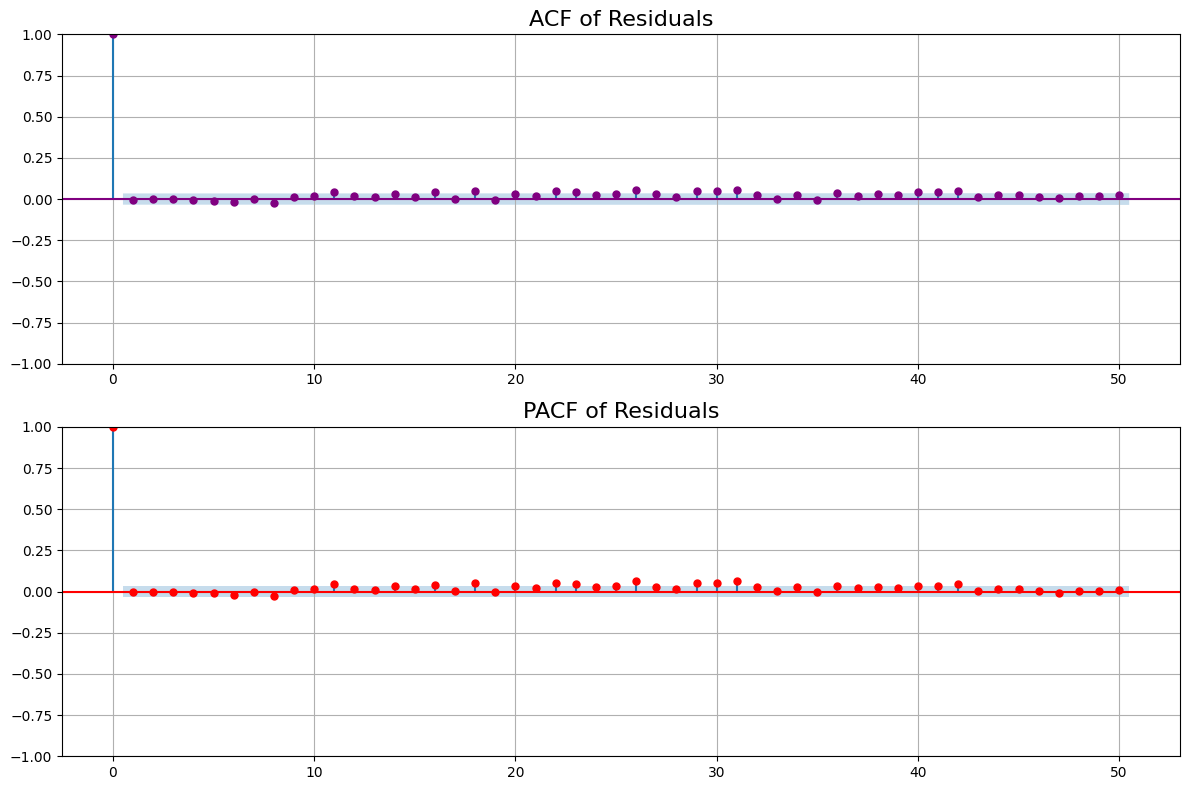

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(residuals, lags=50, ax=ax[0], color='purple')
ax[0].set_title('ACF of Residuals', fontsize=16)
ax[0].grid(True)

plot_pacf(residuals, lags=50, ax=ax[1], color='red')
ax[1].set_title('PACF of Residuals', fontsize=16)
ax[1].grid(True)

plt.tight_layout()
plt.show()